# ASTR620 Project
## Galaxy Bias
### Jonah George
### 5/11/2026
#### You'll need corrfunc and uncertainties for this script

In [2]:
# Initial setup cell

import numpy as np
import matplotlib.pyplot as plt
from routines import common as cmn
import h5py
import os
import numpy as np
from scipy.interpolate import interp1d

# Plotting settings
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

%reload_ext autoreload
%autoreload 2

sim_names = [ 'l0063-bol', 'l0125-bol', 'l0250-bol']

mf_model = 'tinker08'
z = 0.0

In [3]:
# Schechter function, cumulative (for abundance matching)

import scipy
from colossus.lss import mass_function

def schechterFunction(log_L, phi_star, log_Lstar, alpha):
    
    LLstar = 10**log_L / 10**log_Lstar
    lf = np.log(10.0) * phi_star * LLstar**(alpha + 1.0) * np.exp(-LLstar)
    
    return np.log10(lf)

def schechterFunctionMass(M, phi_star, M_knee, alpha, units = 'ln'):
    
    M_M_knee = M / M_knee
    mf = phi_star * M_M_knee**(alpha + 1) * np.exp(-M_M_knee)
    
    if units == 'dn_dln':
        pass
    elif units == 'dn_dlog10':
        mf *= np.log(10.0)
    elif units == 'dn':
        mf /= M
    else:
        raise Exception('Unknown units, %s.' % units)
        
    return mf

def integrandStar(logM, phi_star, M_knee, alpha):
    
    M = 10**logM
    x = schechterFunctionMass(M, phi_star, M_knee, alpha, units = 'dn_dlog10')
    
    return x

def integrandHalo(logM, z, mf_model):
    
    M = 10**logM
    mf = mass_function.massFunction(M, z, q_in = 'M', q_out = 'dndlnM', model = mf_model, mdef = 'vir')
    mf *= np.log(10.0)
    
    return mf

def getCumulative(log_M, func, args = ()):
    
    cumu = np.zeros_like(log_M)
    for i in range(len(log_M) - 1, -1, -1):
        if i == len(log_M) - 1:
            cumu_last = 0.0
            upper_lim = 15.0
        else:
            cumu_last = cumu[i + 1]
            upper_lim = log_M[i + 1]
        I, _ = scipy.integrate.quad(func, log_M[i], upper_lim, args = args)
        cumu[i] = cumu_last + I

    return cumu

In [4]:
# For obtaining data (and getCumulativeMassFunction for abundance matching)

dic = {}
dic['sim_data'] = {}

def getSimData(sim_name):
    
    if not sim_name in dic['sim_data']:
        dic['sim_data'][sim_name] = {}
        fn = os.path.join(cmn.data_dir, 'nbody/tree_%s.hdf5' % (sim_name))
        f = h5py.File(fn, mode = 'r')
        dic['sim_data'][sim_name]['L_box'] = f['simulation'].attrs['box_size']
        dic['sim_data'][sim_name]['m_ptl'] = f['simulation'].attrs['particle_mass']
        
        idxLast = -1
        
        dic['sim_data'][sim_name]['mask_alive'] = np.array(f['mask_alive'][idxLast, :]).astype(bool)
        
        mVir = np.array(f['Mvir'])
        dic['sim_data'][sim_name]['Mvir_curr'] = mVir[idxLast, :]
        
        idxAx = 0
        dic['sim_data'][sim_name]['Mvir_peak'] = np.max(mVir, axis = idxAx)
        
        dic['sim_data'][sim_name]['x'] = np.array(f['x'])
        f.close()

    return dic['sim_data'][sim_name]

def getHaloData(sim_name, mass_def = 'Mvir_peak', minNPtl = 200):
    
    simDic = getSimData(sim_name)

    isM200m = 'M200m' in mass_def
    baseDef = mass_def.replace('M200m', 'Mvir')

    if not baseDef in simDic:
        raise Exception('Could not find mass definition %s in simulation dictionary.' % (baseDef))
        
    mUse = simDic[baseDef]
    mMin = simDic['m_ptl'] * minNPtl
    mask = (mUse >= mMin) & simDic['mask_alive']
    mUse = mUse[mask]

    # convert array to m200m using a fast lookup table (this was to see if changing mass definitions would get b vs. nu results closer to Tinker+10, but it didn't
    if isM200m:
        from colossus.halo import mass_adv
        from scipy.interpolate import interp1d
        
        numZero = 0.0
        # solve the nfw root exactly for 100 points
        mGridVir = np.logspace(10.0, 15.5, 100)
        mGrid200m, _, _ = mass_adv.changeMassDefinitionCModel(mGridVir, numZero, 'vir', '200m', c_model = 'diemer19')
        
        # interpolate instantly across the millions of simulation halos
        interpFunc = interp1d(mGridVir, mGrid200m, kind = 'cubic', fill_value = 'extrapolate')
        mUse = interpFunc(mUse)

    idxLast = -1

    haloDic = {}
    haloDic['m'] = mUse
    haloDic['x'] = simDic['x'][idxLast, mask, :]
    haloDic['L_box'] = simDic['L_box']

    return haloDic

def getCumulativeMassFunction(sim_name, mass_def = 'Mvir_peak', nBins = 50):
    
    k = sim_name + mass_def
    if not k in dic['mf_cumu']:
        dic['mf_cumu'][k] = {}
        haloDic = getHaloData(sim_name, mass_def = mass_def)
        mf, binEdges = np.histogram(np.log10(haloDic['m']), bins = nBins)
        
        idxLast = -1
        bins = 10**binEdges[:idxLast]
        mfCumu = np.cumsum(mf[::-1])[::-1] / haloDic['L_box']**3
    
    numZero = 0
    valid = mfCumu > numZero
    logBins = np.log10(bins[valid])
    logMfCumu = np.log10(mfCumu[valid])
    
    logInterp = interp1d(logBins, logMfCumu, kind = 'cubic', fill_value = 'extrapolate')
    
    def wrapper(x):
        return 10**logInterp(np.log10(x))
        
    return wrapper

In [5]:
# Inputting data from the Zehavi paper

sdss_rp = np.array([
    0.17, 0.27, 0.42, 0.67, 1.1, 1.7, 2.7, 4.2, 6.7, 10.6, 16.9, 26.8, 42.3
])


sdss_magbin = [[-23,-22], [-22,-21], [-21,-20], [-20,-19], [-19,-18], [-18,-17]]

sdss_magbin_wp = np.array([
    [2307.0, 536.1, 297.9, 269.0, 268.4, 211.6],
    [1200.0, 359.0, 231.5, 208.7, 212.1, 203.9],
    [ 713.4, 238.6, 166.4, 152.2, 153.7, 158.1],
    [ 527.2, 148.7, 117.2, 108.8, 109.8, 114.4],
    [ 274.1,  99.1,  79.3,  73.1,  75.1,  79.4],
    [ 155.6,  65.6,  55.8,  48.5,  47.1,  53.0],
    [ 109.7,  47.2,  40.4,  33.8,  31.4,  36.7],
    [  92.0,  34.0,  29.3,  24.2,  18.0,  21.7],
    [  56.1,  23.6,  20.9,  16.2,   9.43, 12.9],
    [  33.2,  14.9,  13.9,   9.94,  5.95,  2.43],
    [  19.4,   8.30,  7.87,  5.00,  3.73,  0.23],
    [  10.3,   4.08,  4.59,  2.47,  1.82, -0.93],
    [   5.21,  2.68,  3.40,  1.11,  0.23, -4.89]
])

sdss_magbin_wp_err = np.array([
    [510.0, 25.4,  9.9, 18.3, 46.7, 64.7],
    [208.0, 12.4,  7.8, 16.3, 37.0, 67.3],
    [100.0,  6.5,  6.6, 13.1, 31.0, 58.7],
    [ 62.0,  4.8,  5.4, 11.2, 22.1, 46.8],
    [ 25.6,  3.2,  4.3,  7.9, 18.0, 34.1],
    [ 15.4,  2.2,  3.6,  6.8, 12.0, 20.8],
    [ 10.7,  2.0,  3.3,  5.2,  7.6, 13.9],
    [  5.9,  1.8,  3.1,  4.0,  4.0,  9.9],
    [  3.8,  1.5,  2.7,  3.3,  2.50,  6.2],
    [  3.1,  1.3,  2.0,  2.03, 1.68, 3.10],
    [  2.3,  0.92, 1.32, 1.53, 1.31, 3.04],
    [  1.7,  0.72, 1.09, 1.68, 1.11, 1.71],
    [  1.26, 0.54, 0.85, 1.28, 1.15, 1.85]
])

# Mag-limited samples

sdss_maglim = [-22.0, -21.5, -21.0, -20.5, -20.0, -19.5, -19.0, -18.5, -18.0]

sdss_maglim_wp = np.array([
    [2615.0, 1028.0, 586.2, 455.7, 366.1, 307.0, 322.5, 313.3, 294.3],
    [1189.0, 731.7, 402.9, 296.9, 264.3, 228.5, 231.1, 230.2, 221.5],
    [728.0, 392.6, 258.7, 197.0, 184.0, 159.3, 162.4, 165.4, 161.4],
    [491.4, 228.6, 163.2, 134.1, 128.6, 110.4, 114.6, 118.3, 114.7],
    [272.8, 144.6, 105.5,  89.4,  84.7,  72.9,  75.5,  79.7,  75.5],
    [154.4,  94.3,  68.9,  61.1,  59.4,  49.8,  50.6,  53.8,  48.6],
    [111.5,  70.5,  50.2,  44.0,  42.9,  34.6,  35.0,  37.4,  32.4],
    [ 94.5,  48.6,  35.5,  31.2,  30.9,  24.6,  24.2,  25.9,  19.7],
    [ 56.8,  33.1,  24.5,  21.3,  21.9,  16.7,  15.3,  17.4,  10.8],
    [ 35.1,  20.9,  15.3,  13.7,  14.6,  10.7,   9.20,  10.6,   6.35],
    [ 22.0,  11.6,   8.54,  7.65,  8.24,   5.73,  4.11,   5.31,  3.62],
    [ 11.4,   6.04,  4.11,  4.09,  4.88,   2.82,  1.81,   3.56,  2.14],
    [  5.89,  3.28,  2.73,  3.21,  3.58,   1.39,  0.72,   0.96,  0.56]
])

sdss_maglim_wp_err = np.array([
    [491.0, 68.0, 19.5, 11.3,  9.3,  9.2, 17.0, 25.9, 34.7],
    [202.0, 34.0, 11.7,  6.9,  7.6,  8.3, 15.3, 24.9, 32.1],
    [ 96.3, 17.1,  6.7,  5.1,  6.6,  7.2, 12.8, 21.1, 27.6],
    [ 55.3, 10.9,  4.7,  4.1,  5.5,  5.6, 10.3, 17.5, 22.0],
    [ 23.2,  6.4,  3.0,  3.3,  4.3,  4.2,  7.7, 13.2, 16.5],
    [ 14.5,  3.7,  2.2,  2.6,  3.6,  3.4,  6.0, 10.5, 11.5],
    [ 10.4,  2.7,  2.1,  2.3,  3.3,  2.9,  4.7,  7.8,  7.7],
    [  5.6,  2.3,  1.8,  2.0,  3.1,  2.5,  3.6,  5.8,  4.4],
    [  3.8,  1.8,  1.6,  1.8,  2.7,  2.4,  2.9,  4.5,  2.8],
    [  3.2,  1.5,  1.3,  1.5,  2.1,  1.9,  1.78, 2.6,  1.93],
    [  2.2,  1.2,  0.94, 1.07, 1.32, 1.28, 1.29, 1.42, 1.34],
    [  1.6,  0.95, 0.71, 0.88, 1.06, 1.13, 1.39, 1.76, 1.23],
    [  1.21, 0.64, 0.54, 0.70, 0.85, 0.91, 1.24, 1.02, 1.26]
])

In [8]:
# Correlation function function

from Corrfunc import theory as cf_theory
h = cmn.cosmo.h



solar_mag_r = 4.76
phi_star_b = 1.49E-2 * h**3
Mstar_b = -20.44 + 5.0 * np.log10(h)
log_Lstar_b = 0.4 * (solar_mag_r - Mstar_b)
alpha_b = -1.05

sdss_log_L = np.linspace(6.0, 12.0, 100)
sdss_mf_cumu = getCumulative(sdss_log_L, integrandStar, args = (phi_star_b, 10**log_Lstar_b, alpha_b))
sdss_mag = solar_mag_r - 2.5 * sdss_log_L - 5.0 * np.log10(h)


def magFromNumberDensity(mf_cumu):
    
    mag = np.interp(mf_cumu, sdss_mf_cumu[::-1], sdss_mag[::-1])

    return mag

dic['mag_from_m'] = {}
for i in range(len(sim_names)):
    for mass_def in ['Mvir_peak', 'Mvir_curr', 'M200m_peak', 'M200m_curr']:
        k = sim_names[i] + mass_def
        dic['mag_from_m'][k] = {}
        dic['mag_from_m'][k]['m'] = np.array(dic['mf_cumu'][k]['bins'])
        dic['mag_from_m'][k]['mag'] = magFromNumberDensity(dic['mf_cumu'][k]['mf_cumu'])


dic['mag_from_m'][mf_model] = {}
dic['mag_from_m'][mf_model]['m'] = np.array(dic['mf_cumu'][mf_model]['bins'])
dic['mag_from_m'][mf_model]['mag'] = magFromNumberDensity(dic['mf_cumu'][mf_model]['mf_cumu'])


def getCorrelationFunction(sim_name, max_mag, min_mag = None, mass_def = 'Mvir_peak', n_bins = 7, n_threads = 4, n_min_halos = 100):

    halo_dic = getHaloData(sim_name, mass_def = mass_def)
    mask = getHaloMask(sim_name, max_mag, min_mag = min_mag, mass_def = mass_def, verbose = True)
    x = halo_dic['x'][mask, :]

    # Check if there are enough halos
    if np.count_nonzero(mask) < n_min_halos:
        if min_mag is not None:
            print('Could not compute correlation function for sim %s, mag %.1f..%.1f, too few halos in sample.' \
                 % (sim_name, min_mag, max_mag))
        else:
            print('Could not compute correlation function for sim %s, mag limit %.1f, too few halos in sample.' \
                 % (sim_name, max_mag))
        return None, None

    L_box = halo_dic['L_box']
    r_bins = 10**np.linspace(np.log10(L_box * 1E-3), np.log10(L_box * 0.1), n_bins)

    pi_max = L_box * 0.49

    ret = cf_theory.wp(L_box, pi_max, n_threads, r_bins, x[:, 0], x[:, 1], x[:, 2])
    
    r_bins_center = 0.5 * (ret['rmin'] + ret['rmax'])
    wp = ret['wp']

    return r_bins_center, wp

In [9]:
# Abundance matching

dic['mf_cumu'] = {}
for i in range(len(sim_names)):
    for mass_def in ['Mvir_peak', 'Mvir_curr', 'M200m_peak', 'M200m_curr']:
        k = sim_names[i] + mass_def
        
        bins = np.logspace(11, 15, 200)
        mf_cumu = getCumulativeMassFunction(sim_names[i], mass_def = mass_def)(bins)
        ####
        
        dic['mf_cumu'][k]['bins'] = bins
        dic['mf_cumu'][k]['mf_cumu'] = mf_cumu
        
dic['mf_cumu'][mf_model] = {}
model_halo_logm = np.linspace(11.0, 15, 100)
dic['mf_cumu'][mf_model]['bins'] = 10**model_halo_logm
dic['mf_cumu'][mf_model]['mf_cumu'] = getCumulative(model_halo_logm, integrandHalo, args = (z, mf_model))

def massFromMag(mag, source, mass_def = 'Mvir_peak'):

    if source == mf_model:
        k = mf_model
    else:
        k = source + mass_def

    m = np.interp(mag, dic['mag_from_m'][k]['mag'][::-1], dic['mag_from_m'][k]['m'][::-1])

    return m

def getHaloMask(sim_name, max_mag, min_mag = None, mass_def = 'Mvir_peak', verbose = True):

    halo_dic = getHaloData(sim_name, mass_def = mass_def)
    min_m = massFromMag(max_mag, sim_name, mass_def = mass_def)
    mask = (halo_dic['m'] >= min_m)
    if min_mag is not None:
        max_m = massFromMag(min_mag, sim_name, mass_def = mass_def)
        mask &= (halo_dic['m'] <= max_m)
        if verbose:
            print('Magnitude bin %.2f..%.2f, def %s gives halo masses of %.2e..%.2e, %d halos.' \
                  % (min_mag, max_mag, mass_def, min_m, max_m, np.count_nonzero(mask)))
    else:
        if verbose:
            print('Magnitude limit %.2f, def %s gives a minimum halo mass of %.2e, %d halos.' \
                  % (max_mag, mass_def, min_m, np.count_nonzero(mask)))

    return mask

/tmp/ipykernel_787/80576249.py:70: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axAm.legend(frameon = False, fontsize = 9)


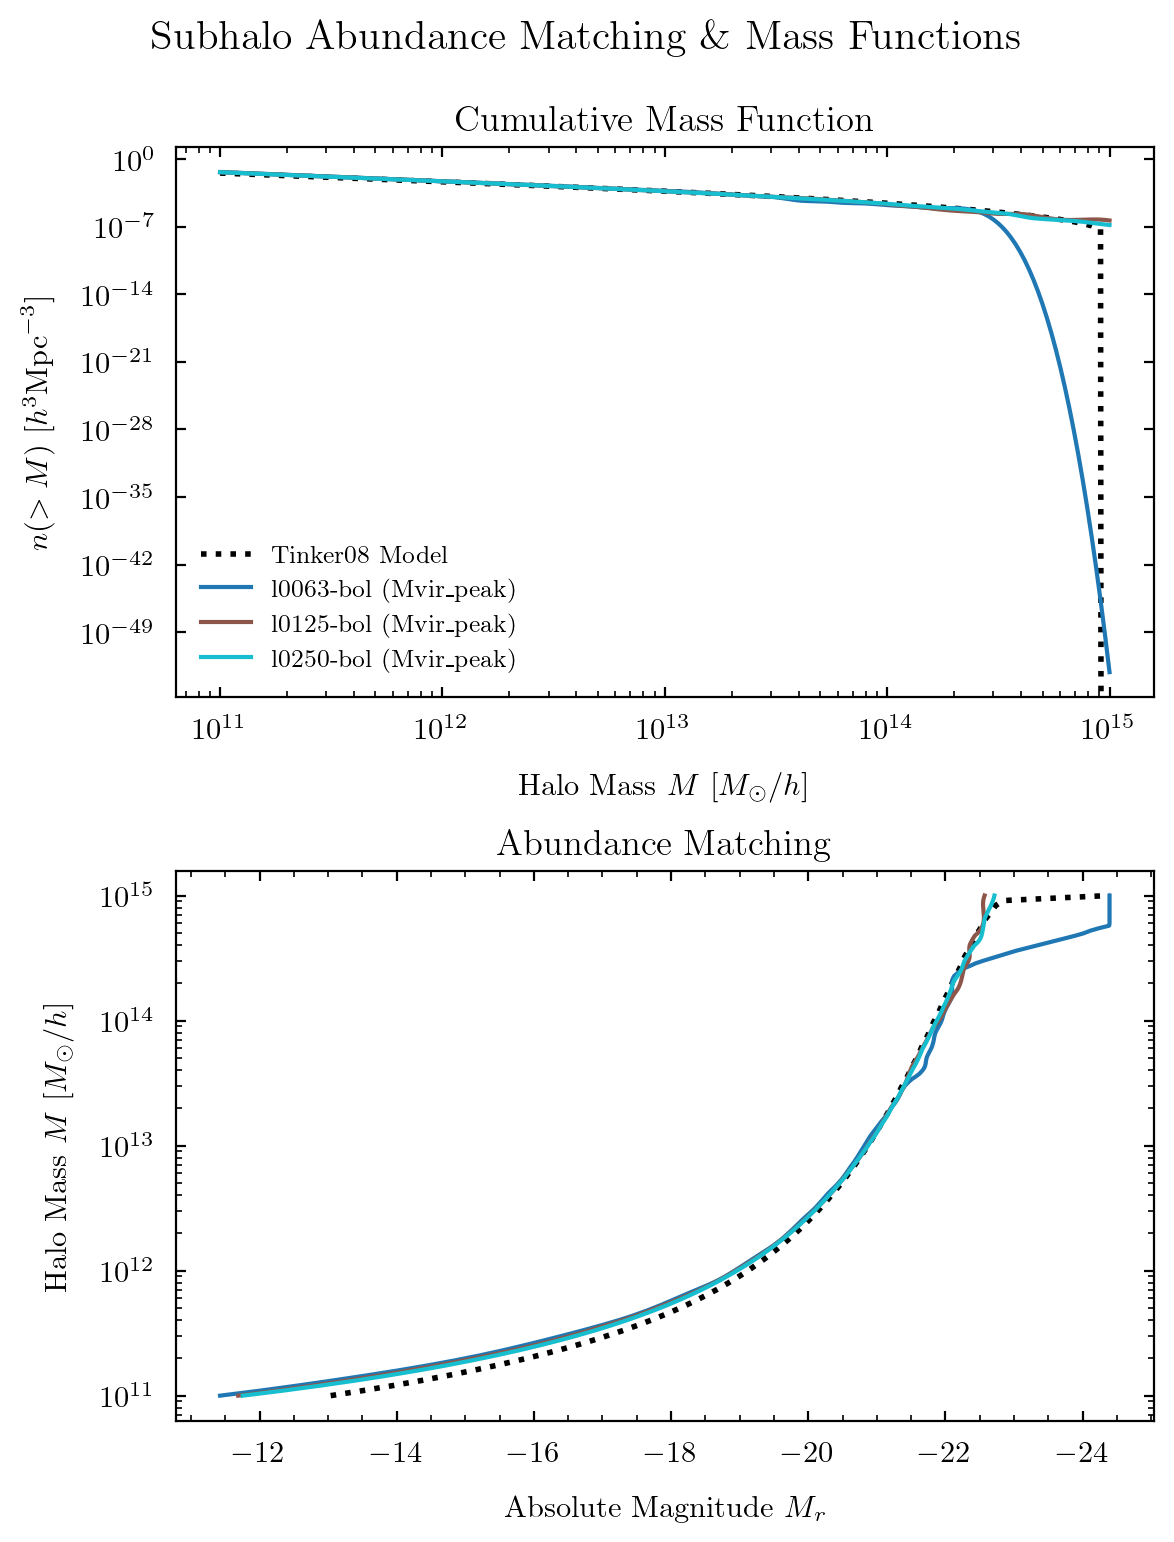

In [10]:
def plot_abundance_matching(massDefs = ('M200m_peak',), horizontal = False, mfModel = 'tinker08'):
    plt.rcParams.update({
        "font.family": "serif",
        "mathtext.fontset": "cm",
        "font.size": 11
    })

    if horizontal:
        fig, axes = plt.subplots(1, 2, figsize = (10, 4.5))
    else:
        fig, axes = plt.subplots(2, 1, figsize = (6, 8))

    fig.suptitle(r'Subhalo Abundance Matching $\&$ Mass Functions', fontsize = 15, y = 0.98 if horizontal else 0.96)

    axMf, axAm = axes.flatten()

    colors = plt.cm.tab10(np.linspace(0, 1, len(sim_names)))

    # plot the theoretical models
    if mfModel in dic['mf_cumu']:
        axMf.plot(dic['mf_cumu'][mfModel]['bins'], dic['mf_cumu'][mfModel]['mf_cumu'],
                  color = 'k', ls = 'dotted', lw = 2, label = f'{mfModel.capitalize()} Model')
                  
    if mfModel in dic['mag_from_m']:
        axAm.plot(dic['mag_from_m'][mfModel]['mag'], dic['mag_from_m'][mfModel]['m'],
                  color = 'k', ls = 'dotted', lw = 2)#, label = f'{mfModel.capitalize()} Mapping')

    for i, simName in enumerate(sim_names):
        c = colors[i]
        for j, md in enumerate(massDefs):
            k = simName + md
            
            lsUse = 'solid' if j == 0 else 'dashed' 
            labelStr = f'{simName} ({md})'

            try:
                bins = dic['mf_cumu'][k]['bins']
                mf = dic['mf_cumu'][k]['mf_cumu']
                axMf.plot(bins, mf, color = c, ls = lsUse, lw = 1.5, label = labelStr)

                mag = dic['mag_from_m'][k]['mag']
                m = dic['mag_from_m'][k]['m']
                axAm.plot(mag, m, color = c, ls = lsUse, lw = 1.5)
            except KeyError:
                continue

    # format mass function axis
    axMf.set_xscale('log')
    axMf.set_yscale('log')
    axMf.set_xlabel(r'Halo Mass $M\ [M_\odot / h]$')
    axMf.set_ylabel(r'$n(>M)\ [h^3 {\rm Mpc}^{-3}]$')
    axMf.tick_params(direction = 'in', which = 'both', top = True, right = True)
    axMf.minorticks_on()
    axMf.legend(frameon = False, fontsize = 9)
    axMf.set_title('Cumulative Mass Function')

    # format abundance matching axis
    axAm.set_yscale('log')
    axAm.set_xlabel(r'Absolute Magnitude $M_r$')
    axAm.set_ylabel(r'Halo Mass $M\ [M_\odot / h]$')
    axAm.invert_xaxis() 
    axAm.tick_params(direction = 'in', which = 'both', top = True, right = True)
    axAm.minorticks_on()
    axAm.set_title('Abundance Matching')
    
    if mfModel in dic['mag_from_m']:
        axAm.legend(frameon = False, fontsize = 9)

    plt.tight_layout()
    # pushed the top margin down further to prevent title overlap
    plt.subplots_adjust(top = 0.85 if horizontal else 0.88)
    plt.savefig('abundance_matching_results.jpg', bbox_inches = 'tight', dpi = 300)
    plt.show()

plot_abundance_matching(massDefs = ('Mvir_peak',), horizontal = False, mfModel = 'tinker08')

In [11]:
# applying the correlation function function to put data in dic

dic['wp'] = {}

for i in range(len(sim_names)):
    for mass_def in ('Mvir_peak', 'Mvir_curr', 'M200m_peak', 'M200m_curr'):
        k = sim_names[i] + mass_def
        dic['wp'][k] = {}
        
        # calculate and store the magnitude bins (left panel)
        magBinIdxs = (5, 4, 3, 2, 1)
        for idx in magBinIdxs:
            min_mag, max_mag = sdss_magbin[idx]
            k2 = '%.2f_%.2f' % (min_mag, max_mag)
            
            r_bins, wp = getCorrelationFunction(sim_names[i], max_mag, min_mag = min_mag, mass_def = mass_def)
            
            dic['wp'][k][k2] = {}
            dic['wp'][k][k2]['r_bins'] = r_bins
            dic['wp'][k][k2]['wp'] = wp
            
        # calculate and store the magnitude limits/thresholds (right panel)
        magLimIdxs = (8, 6, 4, 2, 0)
        for idx in magLimIdxs:
            max_mag = sdss_maglim[idx]
            min_mag = None
            k2 = '%.2f' % (max_mag)
            
            r_bins, wp = getCorrelationFunction(sim_names[i], max_mag, min_mag = min_mag, mass_def = mass_def)
            
            dic['wp'][k][k2] = {}
            dic['wp'][k][k2]['r_bins'] = r_bins
            dic['wp'][k][k2]['wp'] = wp

Magnitude bin -18.00..-17.00, def Mvir_peak gives halo masses of 3.68e+11..5.75e+11, 1151 halos.
Magnitude bin -19.00..-18.00, def Mvir_peak gives halo masses of 5.75e+11..1.06e+12, 959 halos.
Magnitude bin -20.00..-19.00, def Mvir_peak gives halo masses of 1.06e+12..2.82e+12, 714 halos.
Magnitude bin -21.00..-20.00, def Mvir_peak gives halo masses of 2.82e+12..1.40e+13, 355 halos.
Magnitude bin -22.00..-21.00, def Mvir_peak gives halo masses of 1.40e+13..1.22e+14, 79 halos.
Could not compute correlation function for sim l0063-bol, mag -22.0..-21.0, too few halos in sample.
Magnitude limit -18.00, def Mvir_peak gives a minimum halo mass of 5.75e+11, 2110 halos.
Magnitude limit -19.00, def Mvir_peak gives a minimum halo mass of 1.06e+12, 1151 halos.
Magnitude limit -20.00, def Mvir_peak gives a minimum halo mass of 2.82e+12, 437 halos.
Magnitude limit -21.00, def Mvir_peak gives a minimum halo mass of 1.40e+13, 82 halos.
Could not compute correlation function for sim l0063-bol, mag limi

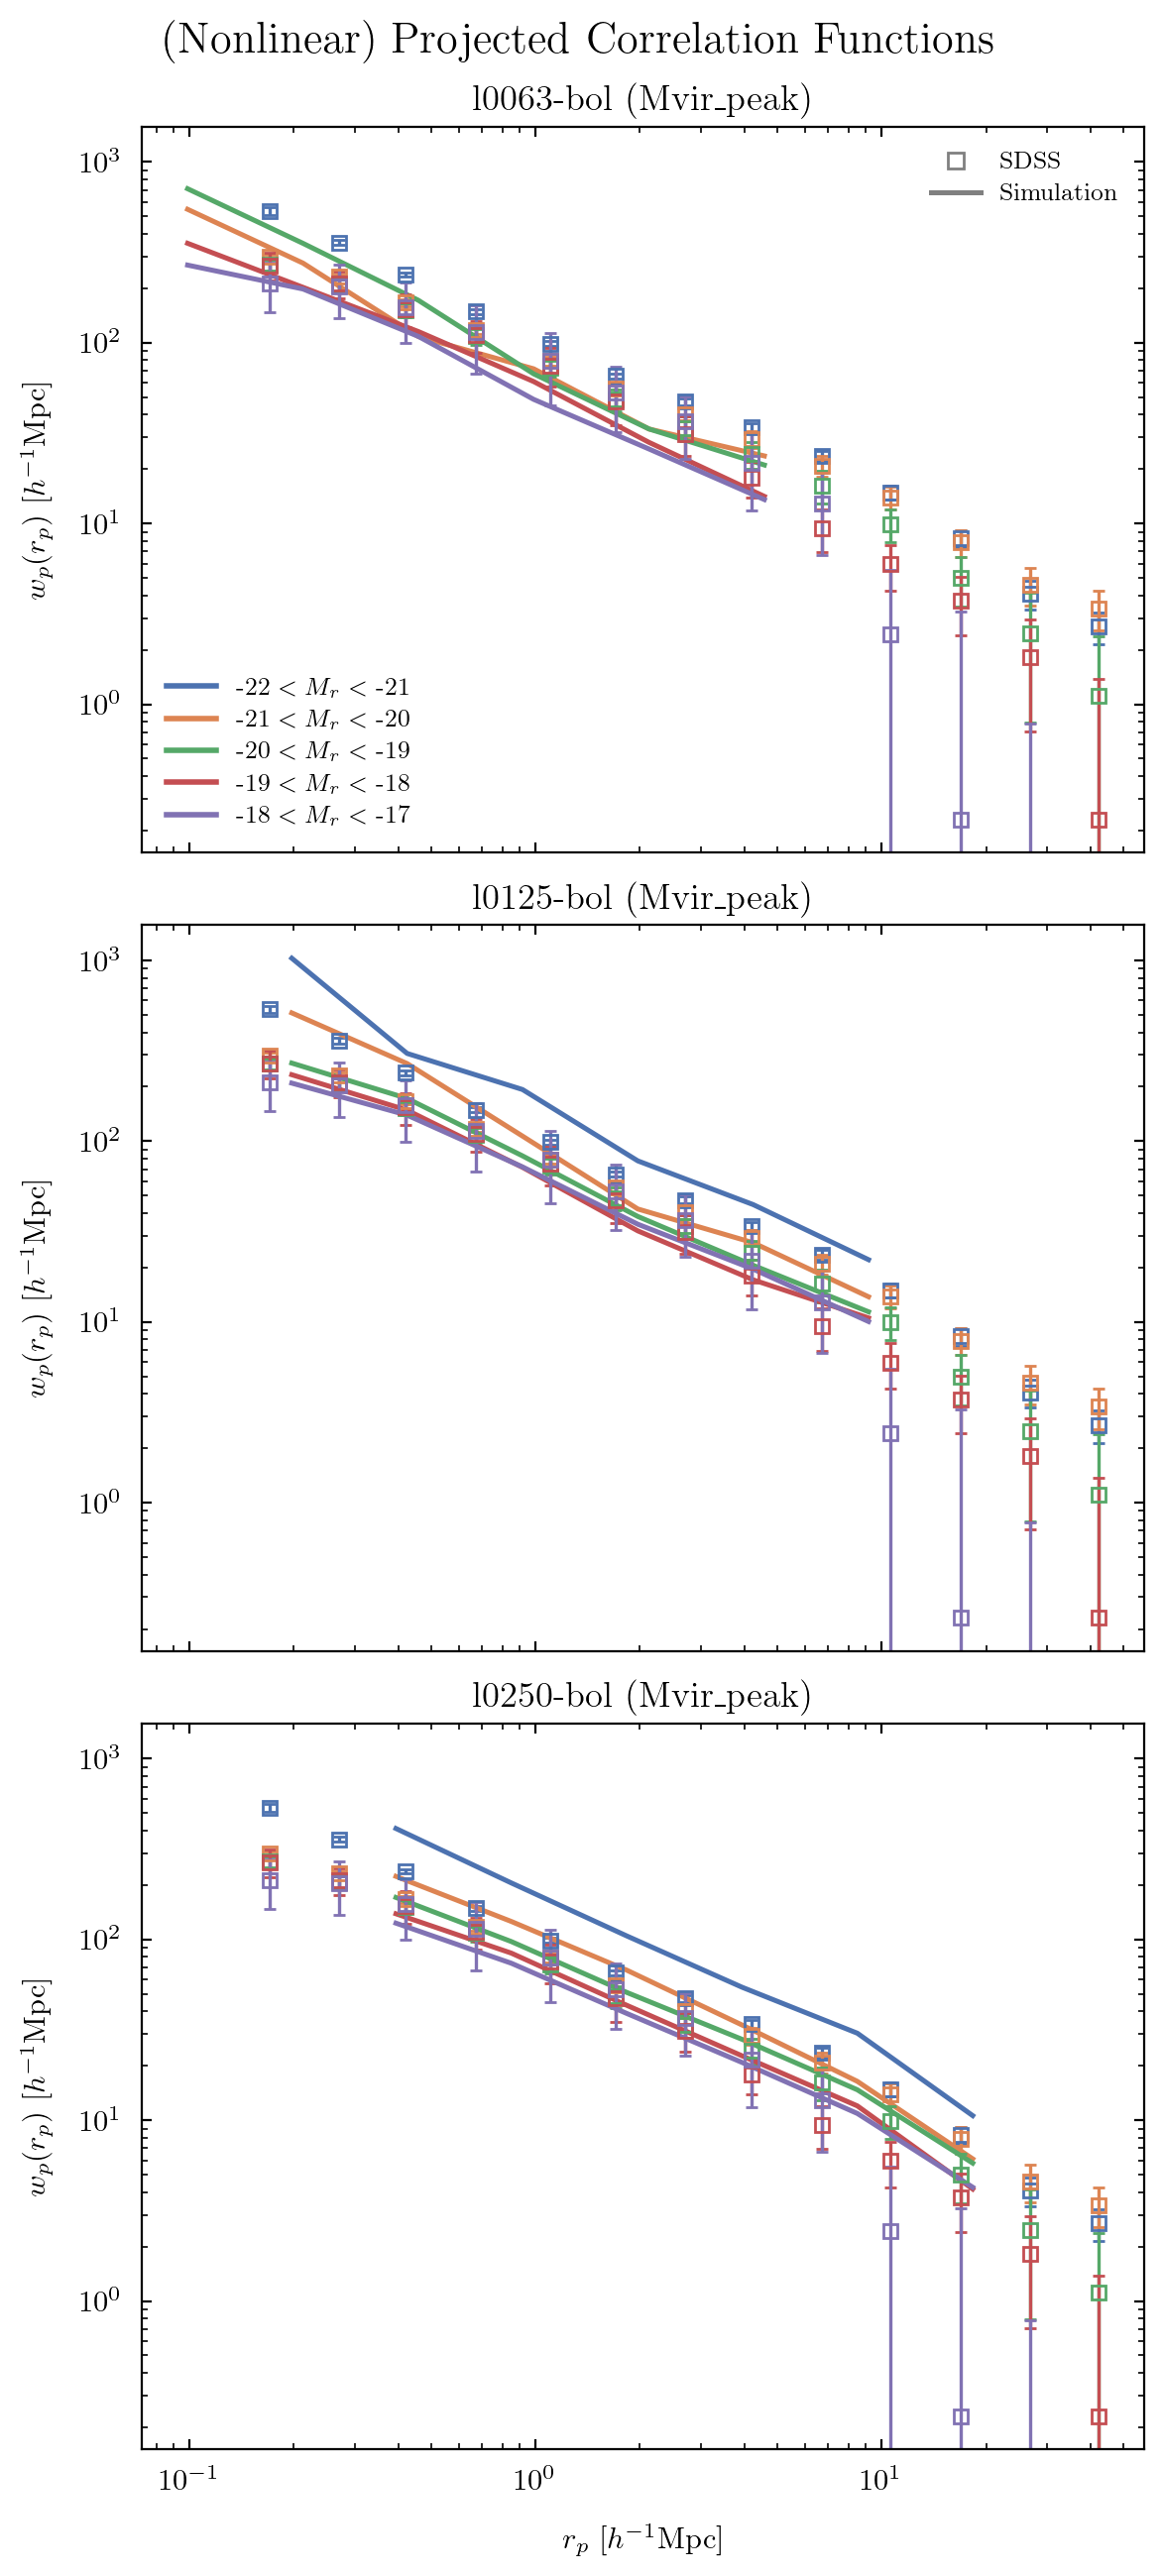

In [51]:
def plotProjectedCorrelation(massDef = 'Mvir_peak', useBins = True, horizontal = True):
    plt.rcParams.update({
        "font.family": "serif",
        "mathtext.fontset": "cm",
        "font.size": 11
    })

    numSims = len(sim_names)
    
    # Dynamically adjust layout based on orientation
    if horizontal:
        fig, axesRaw = plt.subplots(1, numSims, figsize = (5.5 * numSims, 5), sharey = True)
    else:
        fig, axesRaw = plt.subplots(numSims, 1, figsize = (6, 4.5 * numSims), sharex = True, sharey = True)
    
    if numSims == 1:
        axes = (axesRaw,)
    else:
        axes = axesRaw.flatten()

    if useBins:
        magIdxs = (5, 4, 3, 2, 1)
    else:
        magIdxs = (8, 6, 4, 2, 0)
    
    magIdxs = sorted(magIdxs)
    
    colors = ['#4c72b0', '#dd8452', '#55a868', '#c44e52', '#8172b3']

    for i, simName in enumerate(sim_names):
        ax = axes[i]
        
        if horizontal:
            if i == 0:
                ax.set_ylabel(r'$w_p(r_p)\ [h^{-1} {\rm Mpc}]$')
            ax.set_xlabel(r'$r_p\ [h^{-1} {\rm Mpc}]$')
        else:
            ax.set_ylabel(r'$w_p(r_p)\ [h^{-1} {\rm Mpc}]$')
            if i == numSims - 1:
                ax.set_xlabel(r'$r_p\ [h^{-1} {\rm Mpc}]$')
                
        ax.set_title(f'{simName} ({massDef})')
        
        ax.set_xscale('log')
        ax.set_yscale('log')
        ax.tick_params(direction = 'in', which = 'both', top = True, right = True)
        ax.minorticks_on()

        legendLines = []
        
        for j, idx in enumerate(magIdxs):
            c = colors[j]
            
            if useBins:
                min_mag, max_mag = sdss_magbin[idx]
                k2 = '%.2f_%.2f' % (min_mag, max_mag)
                labelStr = rf'{min_mag:.0f} $< M_r <$ {max_mag:.0f}'
                wpSdss = sdss_magbin_wp[:, idx]
                errSdss = sdss_magbin_wp_err[:, idx]
            else:
                max_mag = sdss_maglim[idx]
                k2 = '%.2f' % (max_mag)
                labelStr = rf'$M_r <$ {max_mag:.0f}'
                wpSdss = sdss_maglim_wp[:, idx]
                errSdss = sdss_maglim_wp_err[:, idx]
                
            # plot sdss data with error
            ax.errorbar(sdss_rp, wpSdss, yerr = errSdss, fmt = 's', color = c, 
                        mfc = 'none', ms = 5, lw = 1.2, capsize = 2)
            
            k = simName + massDef
            
            try:
                rBins = dic['wp'][k][k2]['r_bins']
                wpSim = dic['wp'][k][k2]['wp']
                
                # Check if the simulation actually had enough halos to generate data
                if wpSim is not None:
                    ax.plot(rBins, wpSim, color = c, ls = 'solid', lw = 1.8)
            except KeyError:
                pass
                
            if i == 0:
                legendLines.append(plt.Line2D((0, 1), (0, 0), color = c, lw = 2, label = labelStr))

        if i == 0:
            # mag bin legend
            leg1 = ax.legend(handles = legendLines, frameon = False, loc = 'lower left', fontsize = 9)
            ax.add_artist(leg1)
            
            # data type legend
            mockLines = [
                plt.Line2D((0, 1), (0, 0), color = 'gray', marker = 's', mfc = 'none', ls = 'none', label = 'SDSS'),
                plt.Line2D((0, 1), (0, 0), color = 'gray', ls = 'solid', lw = 1.8, label = 'Simulation')
            ]
            ax.legend(handles = mockLines, frameon = False, loc = 'upper right', fontsize = 9)

    plt.suptitle("(Nonlinear) Projected Correlation Functions", fontsize = 16, y = 0.98 if horizontal else 0.96)
    plt.tight_layout()
    plt.subplots_adjust(
        top = 0.85 if horizontal else 0.92, 
        wspace = 0.05 if horizontal else None, 
        hspace = None if horizontal else 0.1
    )
    plt.savefig('projected_correlation_function.jpg', bbox_inches = 'tight', dpi = 300)
    plt.show()

plotProjectedCorrelation(massDef = 'Mvir_peak', useBins = True, horizontal = False)

In [20]:
# Helper functions for getting wp, bias

def get_wp_pair(sim_name, mass_def, k2):
    k = sim_name + mass_def

    r_bins = dic['wp'][k][k2]['r_bins']
    wp_gal = dic['wp'][k][k2]['wp']

    return r_bins, wp_gal

def match_linear_wp(r_bins, r_lin, wp_lin):
    return np.interp(r_bins, r_lin, wp_lin)

def get_bias(sim_name, mass_def, k2, r_lin, wp_lin):

    r_bins, wp_gal = get_wp_pair(sim_name, mass_def, k2)

    if wp_gal is None:
        return None, None

    wp_matter = match_linear_wp(r_bins, r_lin, wp_lin)

    bias = np.sqrt(wp_gal / wp_matter)

    return r_bins, bias

def get_bias_sdss(idx, r_lin, wp_lin):

    wp_matter = match_linear_wp(sdss_rp, r_lin, wp_lin)
    bias = np.sqrt(sdss_wp[:, idx] / wp_matter)

    return sdss_rp, bias

def project_xi_to_wp(rp_bins, r_vals, xi_vals):

    wp = np.zeros_like(rp_bins)

    for i, rp in enumerate(rp_bins):
        mask = r_vals > rp
        r = r_vals[mask]
        xi = xi_vals[mask]

        integrand = r * xi / np.sqrt(r**2 - rp**2)
        wp[i] = 2 * np.trapezoid(integrand, r)

    return wp

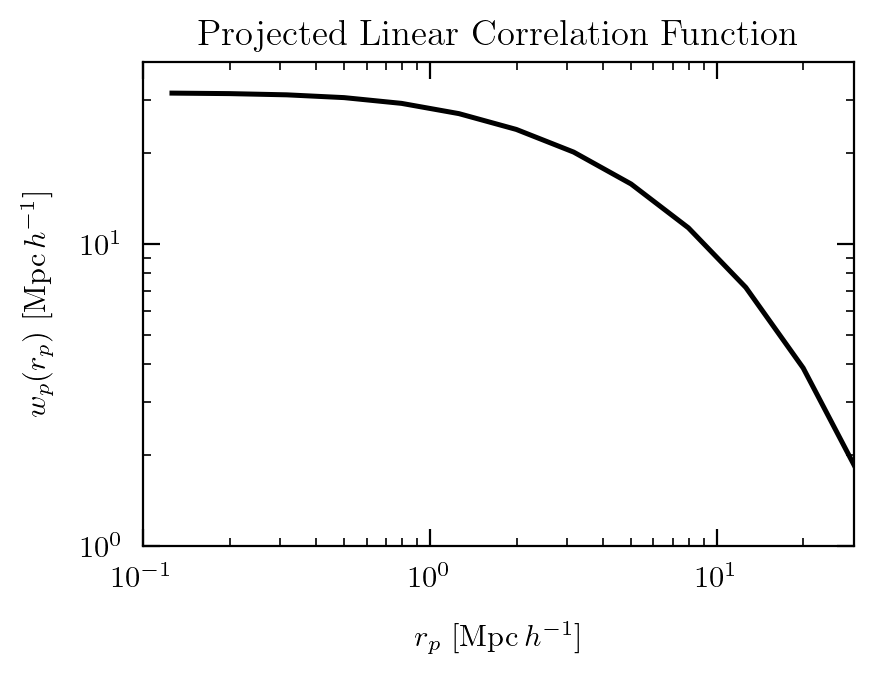

In [27]:
# Plotting the projected linear correlation function

from colossus.cosmology import cosmology

# set up pi integration arrays
piMax = 200.0
dpi = 2.0
piBins = np.arange(0.0, piMax + dpi, dpi)
piCenters = 0.5 * (piBins[:-1] + piBins[1:])

logMin = -1.0   
logMax = 1.5    
dLog = 0.2

cosmo = cosmology.setCosmology('planck18')

rLin = np.logspace(-3, 2, 500)
xiLin = cosmo.correlationFunction(rLin, z = 0.0)
xiInterp = interp1d(rLin, xiLin, kind = 'cubic', bounds_error = False, fill_value = 0.0)

# set up projected rp bins
rpBins = 10**np.arange(logMin, logMax + dLog, dLog)
rpCenters = np.sqrt(rpBins[:-1] * rpBins[1:])

def wpLinear(rp):
    xiVals = xiInterp(np.sqrt(rp**2 + piCenters**2))
    return 2.0 * np.trapezoid(xiVals, piCenters)

wpVals = np.array([wpLinear(rp) for rp in rpCenters])

def plotWpApj(rp, wp):
    plt.rcParams.update({
        "font.family": "serif",
        "mathtext.fontset": "cm",
        "font.size": 11
    })

    fig, ax = plt.subplots(figsize = (4.5, 3.5))

    plt.subplots_adjust(left = 0.15, right = 0.98, top = 0.98, bottom = 0.15)

    ax.set_xscale('log')
    ax.set_yscale('log')

    ax.tick_params(direction = 'in', which = 'both', top = True, right = True)
    ax.minorticks_on()
    ax.tick_params(which = 'major', length = 6)
    ax.tick_params(which = 'minor', length = 3)

    ax.set_xlabel(r'$r_p\ [{\rm Mpc}\,h^{-1}]$')
    ax.set_ylabel(r'$w_p(r_p)\ [{\rm Mpc}\,h^{-1}]$')

    ax.plot(rp, wp, color = 'k', linewidth = 1.8)

    ax.set_xlim(0.1, 30)
    ax.set_ylim(1, 40)

    plt.title('Projected Linear Correlation Function')
    plt.tight_layout()
    plt.savefig('proj_lin_corrfunc.jpg', dpi = 600)
    plt.show()

plotWpApj(rpCenters, wpVals)

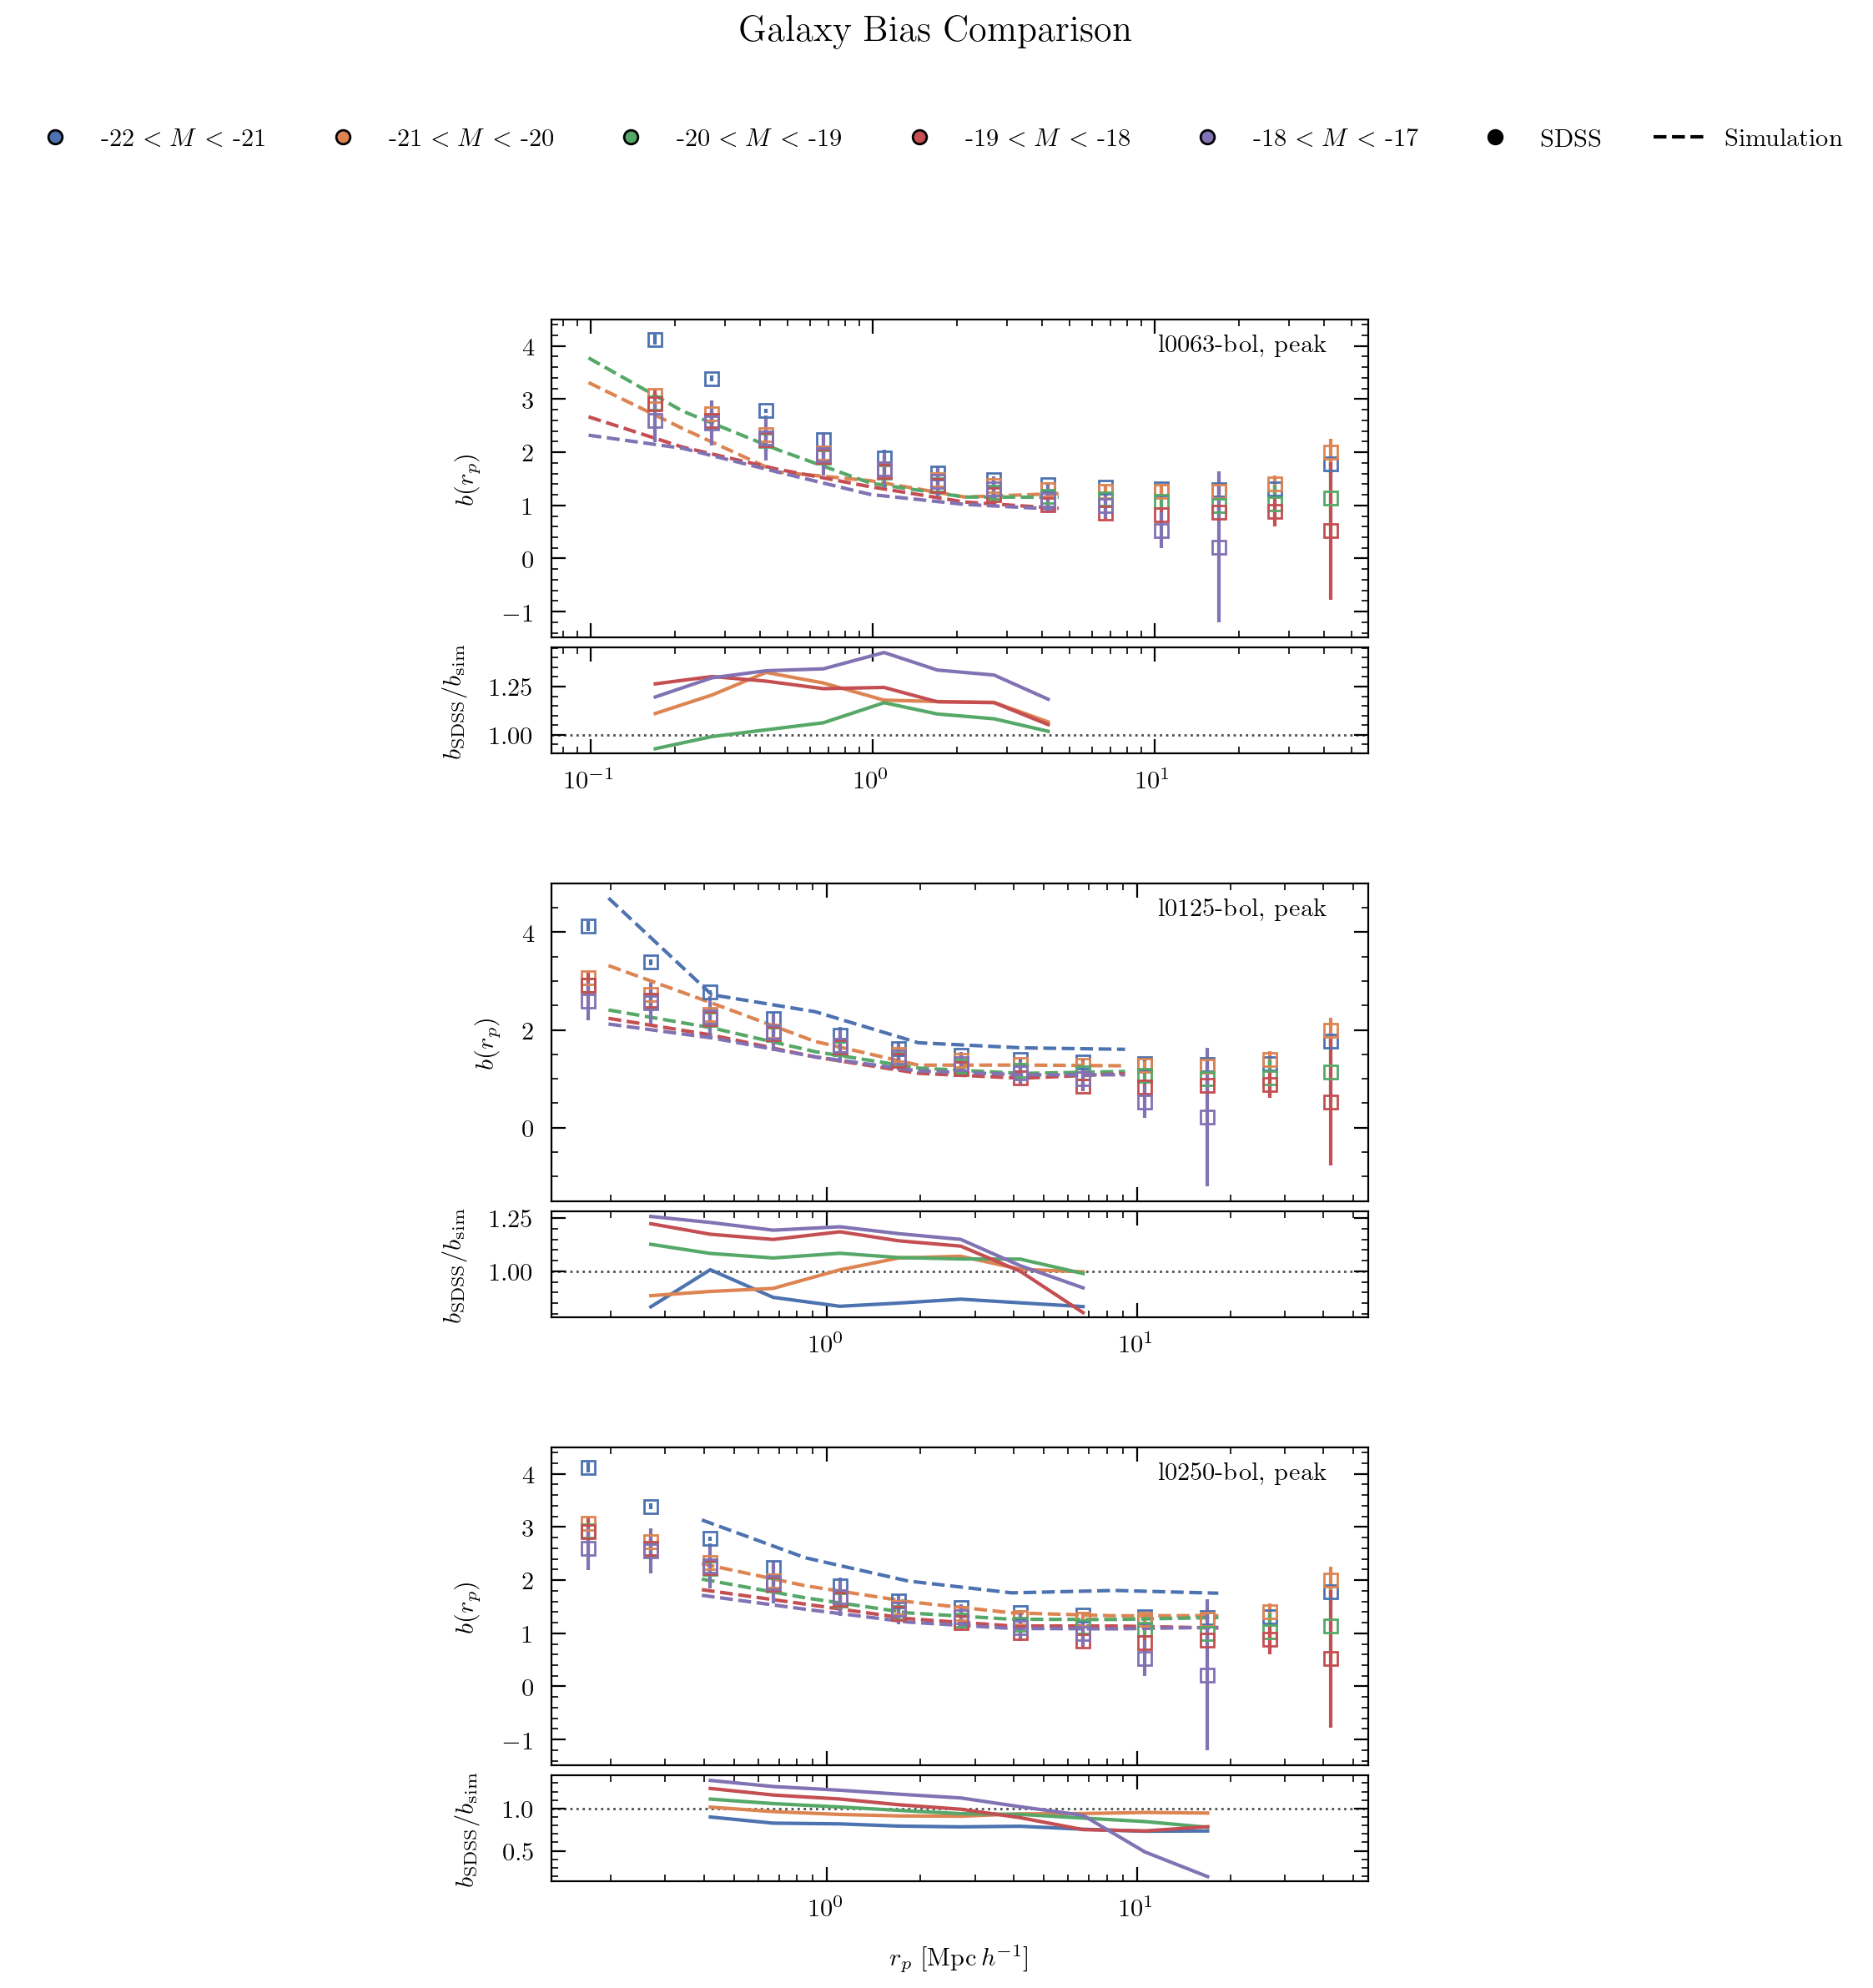

In [50]:
def plotBiasApJ_SDSS_full(use_bins = True, massDefs = ('Mvir_peak',), horizontal = True):

    import matplotlib.pyplot as plt
    import numpy as np
    from uncertainties import unumpy as unp

    colors = ['#4c72b0', '#dd8452', '#55a868', '#c44e52', '#8172b3']

    plt.rcParams.update({
        "font.family": "serif",
        "mathtext.fontset": "cm",
        "font.size": 11
    })

    numSims = len(sim_names)
    numDefs = len(massDefs)

    # dynamically adjust rows, columns, and figure size based on layout choice :)
    if horizontal:
        figWidth = 4.5 * numSims
        figHeight = 4.0 * numDefs + 1.0
        rowsOuter = numDefs
        colsOuter = numSims
    else:
        figWidth = 5.5 * numDefs
        figHeight = 4.0 * numSims + 1.0
        rowsOuter = numSims
        colsOuter = numDefs

    fig = plt.figure(figsize = (figWidth, figHeight))
    fig.suptitle('Galaxy Bias Comparison', fontsize = 16, y = 0.98 if horizontal else 0.96)

    gsOuter = fig.add_gridspec(
        rowsOuter, colsOuter,
        wspace = 0.15 if horizontal else 0.25, 
        hspace = 0.25 if horizontal else 0.3,
        top = 0.82, bottom = 0.10, left = 0.08, right = 0.97
    )

    if use_bins:
        mag_bin_idxs = (5, 4, 3, 2, 1)
        sdssWpU = unp.uarray(sdss_magbin_wp, sdss_magbin_wp_err)
    else:
        mag_bin_idxs = (8, 6, 4, 2, 0)
        sdssWpU = unp.uarray(sdss_maglim_wp, sdss_maglim_wp_err)

    sortedIdxs = sorted(mag_bin_idxs)

    r_lin = np.logspace(-2, 2, 200)
    xi_lin = cosmo.correlationFunction(r_lin, z = 0.0)
    wp_lin = project_xi_to_wp(r_lin, r_lin, xi_lin)

    wpLinSdss = np.array(tuple(wpLinear(rp) for rp in sdss_rp))

    legendElements = []

    for i, simName in enumerate(sim_names):

        for j, massDef in enumerate(massDefs):

            # assign position based on layout orientation
            if horizontal:
                gsTarget = gsOuter[j, i]
            else:
                gsTarget = gsOuter[i, j]

            gsInner = gsTarget.subgridspec(2, 1, hspace = 0.05, height_ratios = (3, 1))
            
            ax1 = fig.add_subplot(gsInner[0])
            ax2 = fig.add_subplot(gsInner[1], sharex = ax1)

            for ax in (ax1, ax2):
                ax.set_xscale('log')
                ax.tick_params(direction = 'in', which = 'both', top = True, right = True)
                ax.minorticks_on()
                ax.tick_params(which = 'major', length = 6)
                ax.tick_params(which = 'minor', length = 3)

            if (horizontal and i == 0) or (not horizontal and j == 0):
                ax1.set_ylabel(r'$b(r_p)$')
                ax2.set_ylabel(r'$b_{\rm SDSS}/b_{\rm sim}$')
            else:
                ax1.tick_params(labelleft = False)
                ax2.tick_params(labelleft = False)

            if (horizontal and j == numDefs - 1) or (not horizontal and i == numSims - 1):
                ax2.set_xlabel(r'$r_p\ [{\rm Mpc}\,h^{-1}]$')
            
            ax1.tick_params(labelbottom = False)
            ax2.axhline(1, color = 'k', linestyle = ':', linewidth = 1, alpha = 0.7)

            labelStr = 'peak' if massDef == 'Mvir_peak' else 'curr'
            ax1.text(0.95, 0.9, f'{simName}, {labelStr}', transform = ax1.transAxes, ha = 'right')

            for k, idx in enumerate(sortedIdxs):

                min_mag, max_mag = sdss_magbin[idx]
                k2 = '%.2f_%.2f' % (min_mag, max_mag)
                c = colors[k]

                if i == 0 and j == 0:
                    legendElements.append(
                        plt.Line2D((0, 1), (0, 0), color = 'none', marker = 'o', markerfacecolor = c, label = rf'{min_mag:.0f} $< M <$ {max_mag:.0f}')
                    )

                r_bins, bias_sim = get_bias(simName, massDef, k2, r_lin, wp_lin)

                if bias_sim is not None:
                    ax1.plot(r_bins, bias_sim, color = c, linestyle = '--')

                ratioSdss = sdssWpU[:, idx] / wpLinSdss
                nom_all = unp.nominal_values(ratioSdss)

                valid = (nom_all > 0) & np.isfinite(nom_all)

                biasSdssU = unp.sqrt(ratioSdss[valid])
                rSdssPlot = sdss_rp[valid]

                nom = unp.nominal_values(biasSdssU)
                err = unp.std_devs(biasSdssU)

                ax1.errorbar(rSdssPlot, nom, yerr = err, marker = 's', mfc = "None", color = c, ls = 'none')

                if bias_sim is not None:

                    bias_sim_interp = np.interp(rSdssPlot, r_bins, bias_sim)

                    ratio = nom / bias_sim_interp
                    ratio[(ratio <= 0) | ~np.isfinite(ratio)] = np.nan

                    mask_interp = (
                        (rSdssPlot >= np.min(r_bins)) &
                        (rSdssPlot <= np.max(r_bins))
                    )

                    ax2.plot(rSdssPlot[mask_interp], ratio[mask_interp], color = c)

    legendElements.append(
        plt.Line2D((0, 1), (0, 0), color = 'k', marker = 'o', linestyle = 'none', label = 'SDSS')
    )
    legendElements.append(
        plt.Line2D((0, 1), (0, 0), color = 'k', linestyle = '--', label = 'Simulation')
    )

    fig.legend(
        handles = legendElements,
        loc = 'upper center',
        ncol = len(sortedIdxs) + 2,
        bbox_to_anchor = (0.5, 0.92),
        frameon = False
    )

    plt.savefig('biasComparison_allSims.jpg', bbox_inches = 'tight', dpi = 300)
    plt.show()

plotBiasApJ_SDSS_full(use_bins = True, massDefs = ('Mvir_peak',), horizontal = False)

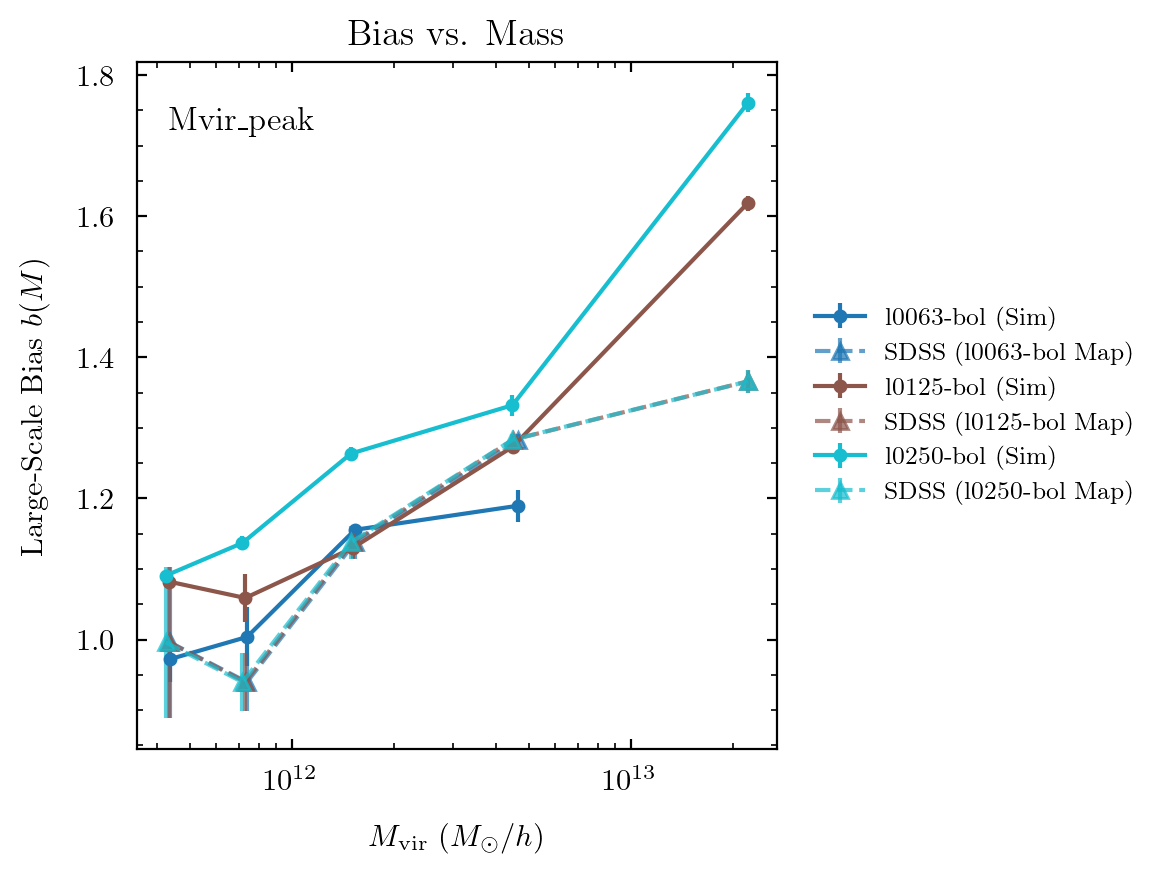

In [49]:
# shared helper function to calculate analytical bias using chi-squared fitting
def fit_bias_chi2(r_bins, wp_gal, r_lin, wp_lin, r_fit_min = 4.0, r_fit_max = 30.0):
    wp_m_full = np.interp(r_bins, r_lin, wp_lin)
    mask = (r_bins > r_fit_min) & (r_bins < r_fit_max)

    if np.sum(mask) < 1:
        return np.nan, np.nan

    wp_g = wp_gal[mask]
    wp_m = wp_m_full[mask]

    valid = (wp_g > 0) & (wp_m > 0) & np.isfinite(wp_g) & np.isfinite(wp_m)
    if np.sum(valid) < 1:
        return np.nan, np.nan

    wp_g = wp_g[valid]
    wp_m = wp_m[valid]

    num = np.sum(wp_g * wp_m)
    denom = np.sum(wp_m**2)

    if denom == 0:
        return np.nan, np.nan

    b2 = num / denom
    if b2 <= 0:
        return np.nan, np.nan

    b = np.sqrt(b2)
    residuals = wp_g - b2 * wp_m
    
    valCount = len(wp_g)
    if valCount > 1:
        sigma2 = np.sum(residuals**2) / (valCount - 1)
        b_err = 0.5 * np.sqrt(sigma2 / denom) / b
    else:
        b_err = np.nan

    return b, b_err


def plot_bias_vs_mass(massDef = ('Mvir_peak',), use_bins = True):
    plt.rcParams.update({
        "font.family": "serif",
        "mathtext.fontset": "cm",
        "font.size": 11
    })

    totalDefs = len(massDef)
    fig, axes_raw = plt.subplots(totalDefs, 1, figsize = (6, 4.5 * totalDefs), sharex = True)
    
    if totalDefs == 1:
        axes = (axes_raw,)
    else:
        axes = axes_raw

    r_lin = np.logspace(-2, 2, 200)
    xi_lin = cosmo.correlationFunction(r_lin, z = 0.0)
    wp_lin = project_xi_to_wp(r_lin, r_lin, xi_lin)
    
    wpLinSdss = np.array(tuple(wpLinear(rp) for rp in sdss_rp))

    if use_bins:
        mag_bin_idxs = (5, 4, 3, 2, 1)
    else:
        mag_bin_idxs = (8, 6, 4, 2, 0)
        
    mag_bin_idxs = sorted(mag_bin_idxs)
    colors = plt.cm.tab10(np.linspace(0, 1, len(sim_names)))

    for idx_md, md in enumerate(massDef):
        ax = axes[idx_md]
        ax.set_ylabel(r'Large-Scale Bias $b(M)$')
        ax.text(0.05, 0.9, md, transform = ax.transAxes, fontsize = 12)

        for s, sim in enumerate(sim_names):
            c = colors[s]
            halo_dic = getHaloData(sim, mass_def = md)

            M_vals, b_sim_vals, b_sim_errs = [], [], []
            b_sdss_vals, b_sdss_errs = [], []

            for idx in mag_bin_idxs:
                if use_bins:
                    min_mag, max_mag = sdss_magbin[idx]
                    k2 = '%.2f_%.2f' % (min_mag, max_mag)
                else:
                    max_mag = sdss_maglim[idx]
                    min_mag = None
                    k2 = '%.2f' % (max_mag)

                r_bins, bias_sim = get_bias(sim, md, k2, r_lin, wp_lin)
                if bias_sim is None: continue

                mask_r = (r_bins > 2.0)
                if np.sum(mask_r) < 1: continue

                b_mean = np.nanmedian(bias_sim[mask_r])
                b_err  = np.nanstd(bias_sim[mask_r]) / np.sqrt(np.sum(mask_r))

                # Extract SDSS bias mapped to this simulation's masses
                if use_bins:
                    wp_sdss = sdss_magbin_wp[:, idx]
                else:
                    wp_sdss = sdss_maglim_wp[:, idx]

                b_sdss, err_sdss = fit_bias_chi2(sdss_rp, wp_sdss, sdss_rp, wpLinSdss)

                mask_halo = getHaloMask(sim, max_mag, min_mag = min_mag, mass_def = md, verbose = False)
                masses = halo_dic['m'][mask_halo]
                if len(masses) < 20: continue

                M_vals.append(np.median(masses))
                b_sim_vals.append(b_mean)
                b_sim_errs.append(b_err)
                b_sdss_vals.append(b_sdss)
                b_sdss_errs.append(err_sdss)

            if len(M_vals) > 0:
                M_vals = np.array(M_vals)
                b_sim_vals = np.array(b_sim_vals)
                b_sim_errs = np.array(b_sim_errs)
                b_sdss_vals = np.array(b_sdss_vals)
                b_sdss_errs = np.array(b_sdss_errs)

                order = np.argsort(M_vals)

                # plot simulation
                ax.errorbar(M_vals[order], b_sim_vals[order], yerr = b_sim_errs[order], fmt = 'o-', color = c, label = f'{sim} (Sim)', ms = 4, lw = 1.5)
                # plot sdss
                ax.errorbar(M_vals[order], b_sdss_vals[order], yerr = b_sdss_errs[order], fmt = '^', color = c, ls = 'dashed', alpha = 0.7, label = f'SDSS ({sim} Map)', ms = 6)

        ax.set_xscale('log')
        ax.tick_params(direction = 'in', which = 'both', top = True, right = True)
        ax.minorticks_on()
        
        # position legend outside the plot so it doesn't cover data points
        ax.legend(frameon = False, fontsize = 9, loc = 'center left', bbox_to_anchor = (1.02, 0.5))
        
        if idx_md == totalDefs - 1:
            ax.set_xlabel(r'$M_{\rm vir}\ (M_\odot / h)$')

    plt.title("Bias vs. Mass")
    plt.tight_layout()
    plt.savefig('bias_vs_mass.jpg', bbox_inches = 'tight', dpi = 300)
    plt.show()

plot_bias_vs_mass(massDef = ('Mvir_peak',))

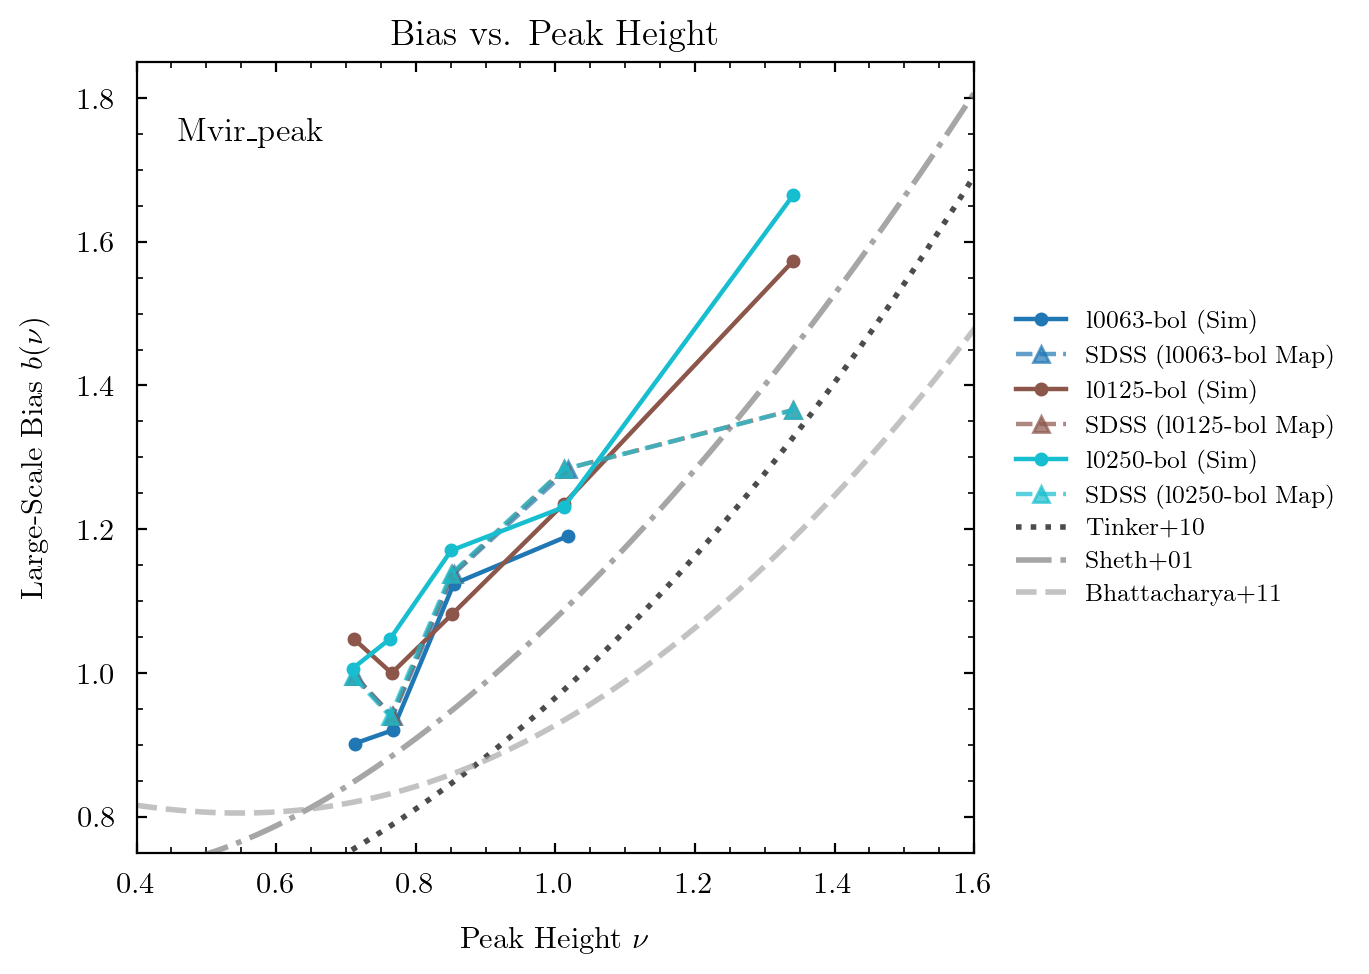

In [48]:
from colossus.lss import peaks
from colossus.lss import bias as halo_bias
from scipy.interpolate import interp1d

def compute_and_plot_bias_vs_nu(massDef = ('M200m_peak',), use_bins = True):
    plt.rcParams.update({
        "font.family": "serif",
        "mathtext.fontset": "cm",
        "font.size": 11
    })

    fig, ax = plt.subplots(figsize = (7, 5))

    if use_bins:
        mag_bin_idxs = (5, 4, 3, 2, 1)
    else:
        mag_bin_idxs = (8, 6, 4, 2, 0)
    mag_bin_idxs = sorted(mag_bin_idxs)

    piMax = 200.0
    dpi = 2.0
    piBins = np.arange(0.0, piMax + dpi, dpi)
    piCenters = 0.5 * (piBins[:-1] + piBins[1:])
    
    rLin_interp = np.logspace(-3, 2, 500)
    xiLin_interp = cosmo.correlationFunction(rLin_interp, z = 0.0)
    xiInterp = interp1d(rLin_interp, xiLin_interp, kind = 'cubic', bounds_error = False, fill_value = 0.0)

    def wpLinear_safe(rp):
        xiVals = xiInterp(np.sqrt(rp**2 + piCenters**2))
        return 2.0 * np.trapezoid(xiVals, piCenters)

    r_lin = np.logspace(-2, 2, 200)
    
    wp_lin = np.array([wpLinear_safe(rp) for rp in r_lin]) 
    wpLinSdss = np.array([wpLinear_safe(rp) for rp in sdss_rp])

    colors = plt.cm.tab10(np.linspace(0, 1, len(sim_names)))
    
    md = next(iter(massDef))
    ax.text(0.05, 0.9, md, transform = ax.transAxes, fontsize = 12)

    for s, simName in enumerate(sim_names):
        c = colors[s]
        
        halo_dic = getHaloData(simName, mass_def = md)

        nu_vals = []
        b_sim_vals = []
        b_sdss_vals = []

        for idx in mag_bin_idxs:
            if use_bins:
                min_mag, max_mag = sdss_magbin[idx]
                k2 = '%.2f_%.2f' % (min_mag, max_mag)
            else:
                max_mag = sdss_maglim[idx]
                min_mag = None
                k2 = '%.2f' % (max_mag)

            k = simName + md

            try:
                r_bins = dic['wp'][k][k2]['r_bins']
                wp_sim = dic['wp'][k][k2]['wp']
            except KeyError:
                continue

            if wp_sim is None: continue

            b_sim, _ = fit_bias_chi2(r_bins, wp_sim, r_lin, wp_lin)
            if not np.isfinite(b_sim): continue

            if use_bins:
                wp_sdss = sdss_magbin_wp[:, idx]
            else:
                wp_sdss = sdss_maglim_wp[:, idx]
                
            b_sdss, _ = fit_bias_chi2(sdss_rp, wp_sdss, sdss_rp, wpLinSdss)
            if not np.isfinite(b_sdss): continue

            mask = getHaloMask(simName, max_mag, min_mag = min_mag, mass_def = md, verbose = False)
            masses = halo_dic['m'][mask]
            if len(masses) < 20: continue

            M = np.median(masses)
            nu = peaks.peakHeight(M, 0.0)

            nu_vals.append(nu)
            b_sim_vals.append(b_sim)
            b_sdss_vals.append(b_sdss)

        if len(nu_vals) > 0:
            nu_arr = np.array(nu_vals)
            b_sim_arr = np.array(b_sim_vals)
            b_sdss_arr = np.array(b_sdss_vals)

            order = np.argsort(nu_arr)
            nu_arr = nu_arr[order]
            b_sim_arr = b_sim_arr[order]
            b_sdss_arr = b_sdss_arr[order]

            ax.plot(nu_arr, b_sim_arr, color = c, ls = 'solid', marker = 'o', ms = 4, lw = 1.6, label = f'{simName} (Sim)')
            ax.plot(nu_arr, b_sdss_arr, color = c, ls = 'dashed', marker = '^', ms = 6, lw = 1.6, alpha = 0.7, label = f'SDSS ({simName} Map)')

    nu_th = np.linspace(0.4, 4.2, 200)
    
    b_tinker = halo_bias.haloBiasFromNu(nu_th, z = 0.0, mdef = '200m', model = 'tinker10')
    ax.plot(nu_th, b_tinker, color = 'k', ls = 'dotted', lw = 2, alpha = 0.7, label = 'Tinker+10')

    b_sheth = halo_bias.haloBiasFromNu(nu_th, z = 0.0, mdef = '200m', model = 'sheth01')
    ax.plot(nu_th, b_sheth, color = 'gray', ls = 'dashdot', lw = 2, alpha = 0.7, label = 'Sheth+01')

    b_bhatt = halo_bias.haloBiasFromNu(nu_th, z = 0.0, mdef = '200m', model = 'bhattacharya11')
    ax.plot(nu_th, b_bhatt, color = 'darkgray', ls = '--', lw = 2, alpha = 0.7, label = 'Bhattacharya+11')

    ax.set_xlabel(r'Peak Height $\nu$')
    ax.set_ylabel(r'Large-Scale Bias $b(\nu)$')

    ax.set_xlim(0.4, 1.6)
    
    ax.set_ylim(0.75, 1.85) 

    ax.tick_params(direction = 'in', which = 'both', top = True, right = True)
    ax.minorticks_on()
    
    ax.legend(frameon = False, fontsize = 9, loc = 'center left', bbox_to_anchor = (1.02, 0.5))

    plt.title("Bias vs. Peak Height")
    plt.tight_layout()
    plt.savefig('bias_vs_nu_multimodel.jpg', bbox_inches = 'tight', dpi = 300)
    plt.show()

compute_and_plot_bias_vs_nu(massDef = ('Mvir_peak',))

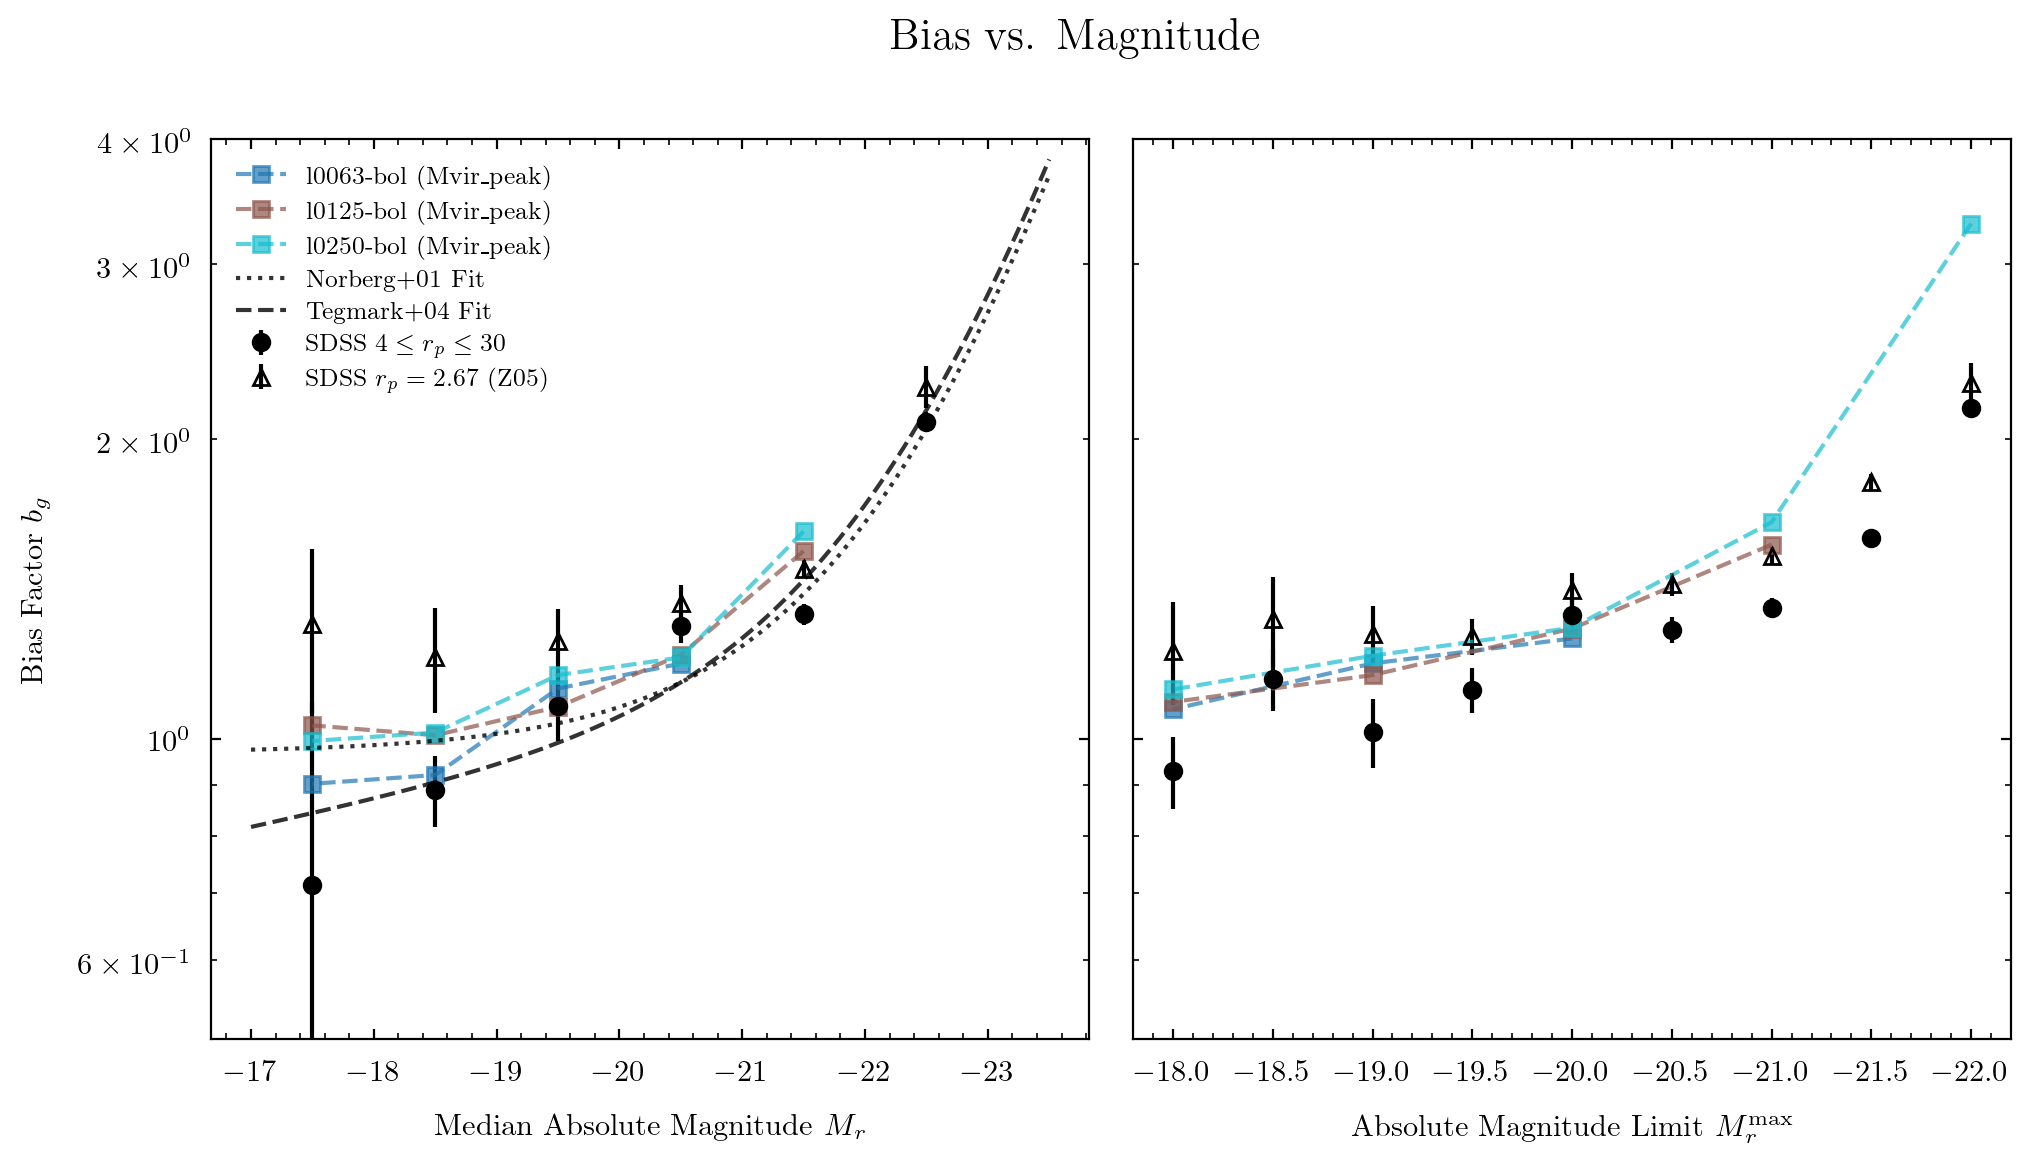

In [46]:
from uncertainties import unumpy as unp

def plotZehaviFig7(massDef = ('Mvir_peak',)):
    plt.rcParams.update({
        "font.family": "serif",
        "mathtext.fontset": "cm",
        "font.size": 11
    })

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize = (12, 6), sharey = True)
    plt.subplots_adjust(wspace = 0.05)

    ax1.set_xlabel(r'Median Absolute Magnitude $M_r$')
    ax2.set_xlabel(r'Absolute Magnitude Limit $M_r^{\rm max}$')
    ax1.set_ylabel(r'Bias Factor $b_g$')

    wpLinSdss = np.array(tuple(wpLinear(rp) for rp in sdss_rp))
    
    rLin = np.logspace(-2, 2, 200)
    wpLin = np.array(tuple(wpLinear(rp) for rp in rLin))

    def get_zehavi_biases(ratio_obs, rp_obs):
        valid = unp.nominal_values(ratio_obs) > 0
        
        maskLarge = valid & (rp_obs >= 4.0) & (rp_obs <= 30.0)
        if np.any(maskLarge):
            bLargeArr = unp.sqrt(ratio_obs[maskLarge])
            bLargeMean = np.sum(bLargeArr) / len(bLargeArr) 
            bLargeNom = float(unp.nominal_values(bLargeMean))
            bLargeErr = float(unp.std_devs(bLargeMean))
        else:
            bLargeNom, bLargeErr = np.nan, np.nan
            
        idx267 = np.argmin(np.abs(rp_obs - 2.67))
        if valid[idx267]:
            b267U = unp.sqrt(ratio_obs[idx267])
            b267Nom = float(unp.nominal_values(b267U))
            b267Err = float(unp.std_devs(b267U))
        else:
            b267Nom, b267Err = np.nan, np.nan
            
        return bLargeNom, bLargeErr, b267Nom, b267Err

    # left panel: sdss luminosity bins
    xBin, bLargeBin, eLargeBin, b267Bin, e267Bin = [], [], [], [], []
    sdssBinWpU = unp.uarray(sdss_magbin_wp, sdss_magbin_wp_err)
    
    for idx, binVals in enumerate(sdss_magbin):
        minMag, maxMag = binVals
        xVal = (minMag + maxMag) / 2.0
        
        ratio = sdssBinWpU[:, idx] / wpLinSdss
        bL, eL, b2, e2 = get_zehavi_biases(ratio, sdss_rp)
        
        xBin.append(xVal)
        bLargeBin.append(bL)
        eLargeBin.append(eL)
        b267Bin.append(b2)
        e267Bin.append(e2)

    ax1.errorbar(xBin, bLargeBin, yerr = eLargeBin, marker = 'o', color = 'k', mfc = 'k', ls = 'none', label = r'SDSS $4 \leq r_p \leq 30$')
    ax1.errorbar(xBin, b267Bin, yerr = e267Bin, marker = '^', color = 'k', mfc = 'none', ls = 'none', label = r'SDSS $r_p = 2.67$ (Z05)')

    # right panel: sdss luminosity thresholds
    xLim, bLargeLim, eLargeLim, b267Lim, e267Lim = [], [], [], [], []
    sdssLimWpU = unp.uarray(sdss_maglim_wp, sdss_maglim_wp_err)
    
    for idx, maxMag in enumerate(sdss_maglim):
        xVal = maxMag
        ratio = sdssLimWpU[:, idx] / wpLinSdss
        bL, eL, b2, e2 = get_zehavi_biases(ratio, sdss_rp)
        
        xLim.append(xVal)
        bLargeLim.append(bL)
        eLargeLim.append(eL)
        b267Lim.append(b2)
        e267Lim.append(e2)

    ax2.errorbar(xLim, bLargeLim, yerr = eLargeLim, marker = 'o', color = 'k', mfc = 'k', ls = 'none')
    ax2.errorbar(xLim, b267Lim, yerr = e267Lim, marker = '^', color = 'k', mfc = 'none', ls = 'none')

    cIter = iter(plt.cm.tab10(np.linspace(0, 1, len(sim_names) * len(massDef))))
    
    for simName in sim_names:
        for md in massDef:
            c = next(cIter)
            dictKey = simName + md
            
            simXBin, simYBin = [], []
            simXLim, simYLim = [], []
            
            if dictKey in dic['wp']:
                for k2 in dic['wp'][dictKey].keys():
                    try:
                        rBins, bSim = get_bias(simName, md, k2, rLin, wpLin)
                        if bSim is not None:
                            validSim = (bSim > 0) & (rBins >= 4.0) & (rBins <= 30.0)
                            if np.any(validSim):
                                meanB = np.nanmean(bSim[validSim])
                                
                                # sort keys into bins (contains underscore) or limits
                                if '_' in k2:
                                    minStr, maxStr = k2.split('_')
                                    xVal = (float(minStr) + float(maxStr)) / 2.0
                                    simXBin.append(xVal)
                                    simYBin.append(meanB)
                                else:
                                    simXLim.append(float(k2))
                                    simYLim.append(meanB)
                    except Exception:
                        pass
            
            # sort arrays to prevent zigzagging lines
            if len(simXBin) > 0:
                sortIdxBin = np.argsort(simXBin)
                ax1.plot(np.array(simXBin)[sortIdxBin], np.array(simYBin)[sortIdxBin], marker = 's', ls = 'dashed', color = c, alpha = 0.7, label = f'{simName} ({md})')
                
            if len(simXLim) > 0:
                sortIdxLim = np.argsort(simXLim)
                ax2.plot(np.array(simXLim)[sortIdxLim], np.array(simYLim)[sortIdxLim], marker = 's', ls = 'dashed', color = c, alpha = 0.7)

    # analytic fits
    mSmooth = np.linspace(-17.0, -23.5, 100)
    mStar = -20.5
    bStar = 1.14
    lRatio = 10**(-0.4 * (mSmooth - mStar))
    
    norbergFit = bStar * (0.85 + 0.15 * lRatio)
    tegmarkFit = bStar * (0.85 + 0.15 * lRatio - 0.04 * (mSmooth - mStar))
    
    ax1.plot(mSmooth, norbergFit, 'k:', linewidth = 1.5, alpha = 0.8, label = 'Norberg+01 Fit')
    ax1.plot(mSmooth, tegmarkFit, 'k--', linewidth = 1.5, alpha = 0.8, label = 'Tegmark+04 Fit')

    # formatting
    for ax in (ax1, ax2):
        ax.invert_xaxis()
        ax.tick_params(direction = 'in', which = 'both', top = True, right = True)
        ax.minorticks_on()

    plt.suptitle('Bias vs. Magnitude', y = 1.05, x = 0.56, fontsize = 16)
    ax1.legend(frameon = False, fontsize = 9, loc = 'upper left')
    plt.ylim(0.5, 4.0)
    plt.semilogy()
    plt.savefig('Zehavi_Fig7_Replica.jpg', bbox_inches = 'tight', dpi = 300)
    plt.show()

plotZehaviFig7(massDef = ('Mvir_peak',))